### Описание задачи
Крушение «Титаника» — одна из самых известных морских катастроф в истории.

15 апреля 1912 года, во время своего первого рейса, считавшийся практически «непотопляемым» лайнер RMS Titanic затонул после столкновения с айсбергом. К сожалению, спасательных шлюпок оказалось недостаточно для всех находившихся на борту, в результате чего погибли 1502 человека из 2224 пассажиров и членов экипажа.

Хотя в выживании присутствовал элемент случайности, кажется, что некоторые группы людей имели больше шансов спастись, чем другие.

В этом соревновании вам предлагается построить предсказательную модель, отвечающую на вопрос: «Кто среди пассажиров имел больше шансов выжить?».  
Для этого нужно использовать данные о пассажирах (имя, возраст, пол, социально-экономический класс и другие характеристики.)

### Цель
Задача — предсказать, выжил ли пассажир при крушении «Титаника» или нет.
Для каждого пассажира из тестового набора нужно предсказать значение переменной: 0 или 1.

### Метрика
Результат оценивается по доле пассажиров, которых вы предсказали правильно.
Эта метрика называется accuracy (точность классификации).

[1] Will Cukierski. Titanic - Machine Learning from Disaster. https://kaggle.com/competitions/titanic, 2012. Kaggle

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path
import importlib

from matplotlib.colors import LinearSegmentedColormap


In [2]:
sys.path.append(str(Path().resolve().parent))

COLOR1 = "#069AF3"
COLOR2 = "#FC5A50"
COLOR3 = "#AAFF32"
COLOR4 = "#000080"

custom_cmap = LinearSegmentedColormap.from_list(
    'my_cmap',
    [COLOR1, COLOR2]
)

In [17]:
test_data = pd.read_csv("../data/test.csv")
train_data= pd.read_csv("../data/train.csv")

In [4]:
train_data.info()
print("\n\nкол-во NaN, None")
train_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


кол-во NaN, None


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Видим незаполненные записи=> далее нужно будет заполнить их или отбросить.

In [5]:
train_data.head()
#Pclass - статус 1st = Upper 2nd = Middle 3rd = Lower
#SibSp сколько братьев, систер, супругов было на борту
#Parch сколько родителей/детей было на борту
#Fare стоимость проезда- (бизнес класс или ??0. = сотрудник?)
#Cabin - номер кабины
#Embarked - место посадки в титаник

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Список столбцов с численным типом:\n",list(train_data.describe().columns))

Список столбцов с численным типом:
 ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


### Разделим численные и категориальные (+порядковые фичи)

In [7]:
train_data_num = train_data[['Survived','Pclass','Age','SibSp','Parch','Fare']].copy()
train_data_cat = train_data[['Survived','Sex','Ticket','Cabin','Embarked']].copy()

## Начнем с категориальных фичей

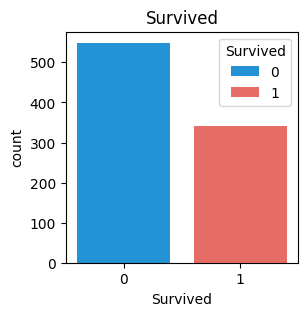

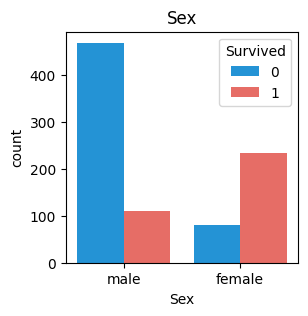

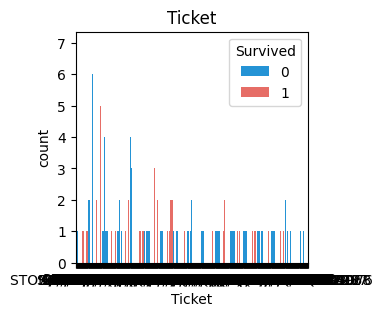

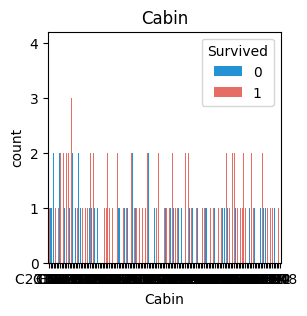

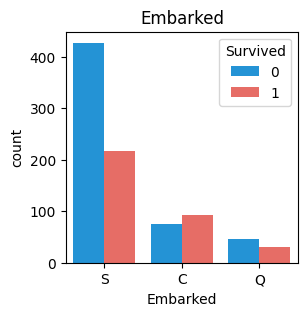

In [8]:
#Посмотрим какие бывают варианты категорий внутри каждой фичи
for feature in train_data_cat:
    plt.figure(figsize=(3, 3))
    sns.countplot(data=train_data_cat, x=feature,hue="Survived", palette= [COLOR1, COLOR2])
    plt.title(feature)
    plt.show()

#### Билет и кабина представляются сомнительными признаками, поскольку обладают высокой вариативностью и близки по смыслу к идентификаторам.
По признаку билета встречаются случаи, когда с одним и тем же билетом  
связано несколько пассажиров. Это может объясняться, тем, что они являются родственниками или знакомыми. Более детальный анализ данного признака возможен, однако его целесообразно оставить на случай, если итоговое качество модели окажется недостаточным. Для признака кабины принимается аналогичный подход.
### UPD: Cabin проанализировал в самом конце

### Embarked - место посадки пассажиров
Наблюдается связь: кол-во выживших из "С" более чем из "Q", а из "S" меньше всего выживших.  
Отбрасывать данную фичу не будем, но проанализируем чуть подробнее позже с учетом численных фич.

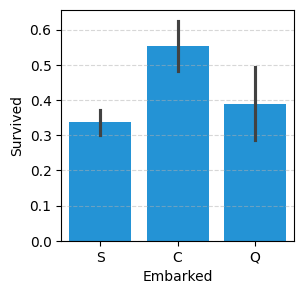

In [9]:
plt.figure(figsize=(3, 3))
sns.barplot(data=train_data_cat, x="Embarked", y="Survived", color= COLOR1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

### Sex - пол пассажиров
На графике видно, что доля выживших среди женщин заметно выше, чем среди мужчин.  
Можно объяснить правилом, что в первую очередь спасают женщин и детей.  
Признак оставляем, так как он, вероятно, будет полезен модели.

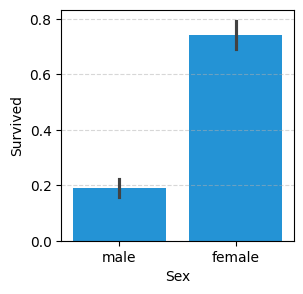

In [10]:
plt.figure(figsize=(3, 3))
sns.barplot(data=train_data_cat, x="Sex", y="Survived", color= COLOR1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

## Численные фичи
Посмотрим есть ли корреляция между числовыми фичами.
Важно заметить, что возраст имеет пропуски (около 20% в train),  
данные пропуски будут обработаны на этапе обработке признаков.

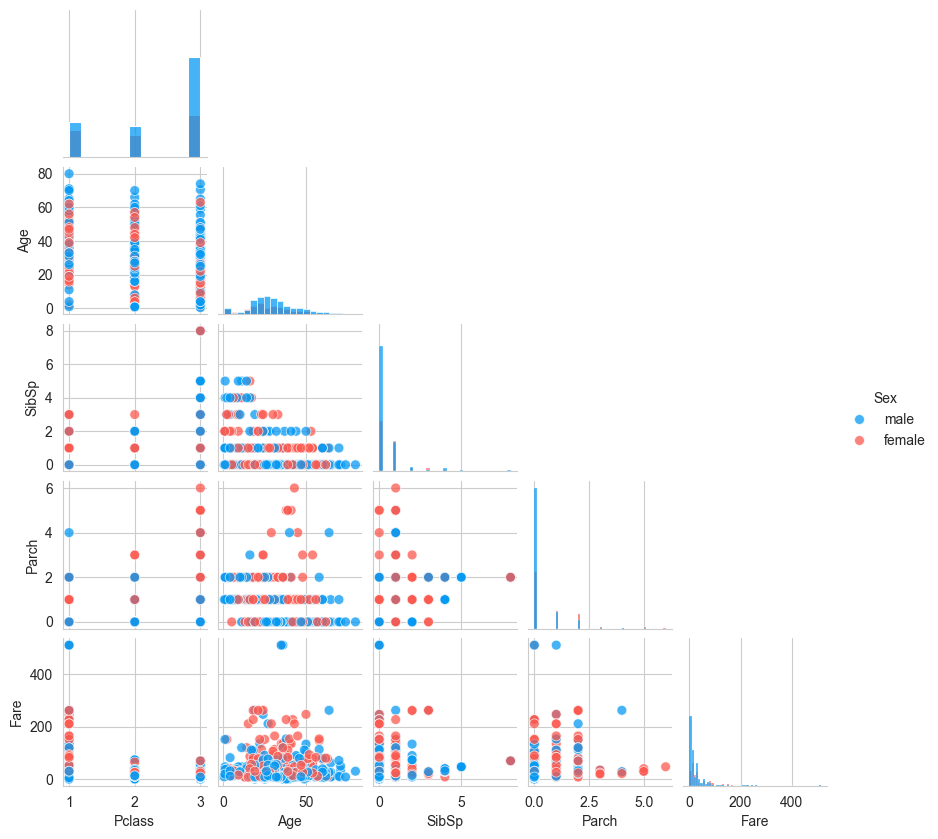

In [11]:
sns.set_style("whitegrid")
train_data_num_with_Sex = train_data_num.copy()
train_data_num_with_Sex["Sex"] = train_data["Sex"]
train_data_num_with_Sex = train_data_num_with_Sex.drop(columns=['Survived'])
g = sns.pairplot(train_data_num_with_Sex, hue = "Sex",palette=[COLOR1, COLOR2], corner=True,diag_kind='hist',  height=1.7,  
     plot_kws={
        'alpha': 0.75,
        's': 50
    },
    diag_kws={'alpha': 0.75})

По графикам корреляция не наблюдается, посчитаем основные коэф. корреляции.  
Воспользуемся коэф. корр. Пирсона для обнаружения линейной связи,  
тк некоторые фичи условно численные (скорее категориальные)  
воспользуемся также коэф. корр. Спирмена.

In [12]:
corr_Pearson = train_data_num.corr(method="pearson")
corr_Spearman = train_data_num.corr(method="spearman")
#print("\n\nPearson:\n",corr_Pearson)
#print("\n\nSpearman:\n",corr_Spearman)


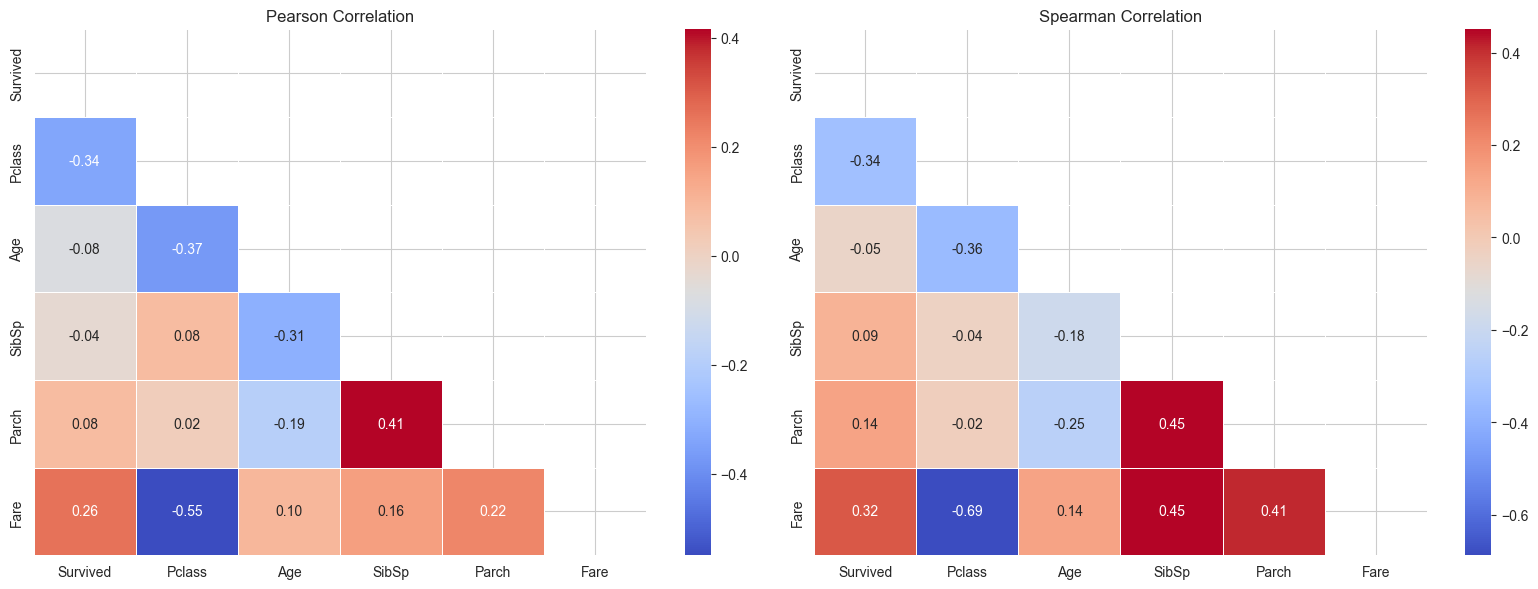

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(corr_Pearson, dtype=bool))
sns.heatmap(
    corr_Pearson,
    mask=mask,
    annot=True,      # показать числа
    cmap='coolwarm', # цветовая схема
    fmt='.2f',       # 2 знака после запятой
    linewidths=0.5,
    ax=ax[0]
)
ax[0].set_title('Pearson Correlation')
sns.heatmap(
    corr_Spearman,
    mask=mask,
    annot=True,      # показать числа
    cmap='coolwarm', # цветовая схема
    fmt='.2f',       # 2 знака после запятой
    linewidths=0.5,
    ax=ax[1]
)
ax[1].set_title('Spearman Correlation')


plt.tight_layout()
#plt.show()


### В целом корреляции между численными фичами нет
Имеется небольшая корреляция Pclass-Fare, что ожидаемо  
чем выше класс- тем дороже билет.

### SibSp, Parch - родственники на борту

#### SibSp (братья, сестра, партнеры) - наблюдаем экстремум у значения "1".  
То есть если Вы одиноки - выше шанс умереть и чем больше у Вас родственником- тоже выше шанс умереть.  
В любом случае, фича важная- оставляем точно.

#### Parch (родители, дети) -тут зависимость не такая простая,  
тк случаев с Parch=3 не много и доверительный интервал говорит,  
что не стоит ориентироваться на это среднее (=долю выживших при Parch=3).  
Но ананлогичная зависимость для 0,1 и с оговорками >=2 есть- фичу оставляем.

#### Тест доработки фичей
Так как имеется широкий CI (полученный в sns с помощью bootstrap) ближе к [3, 4] у обоих фич,  
возможно стоит на этапе добавления фич сделать фичу: train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

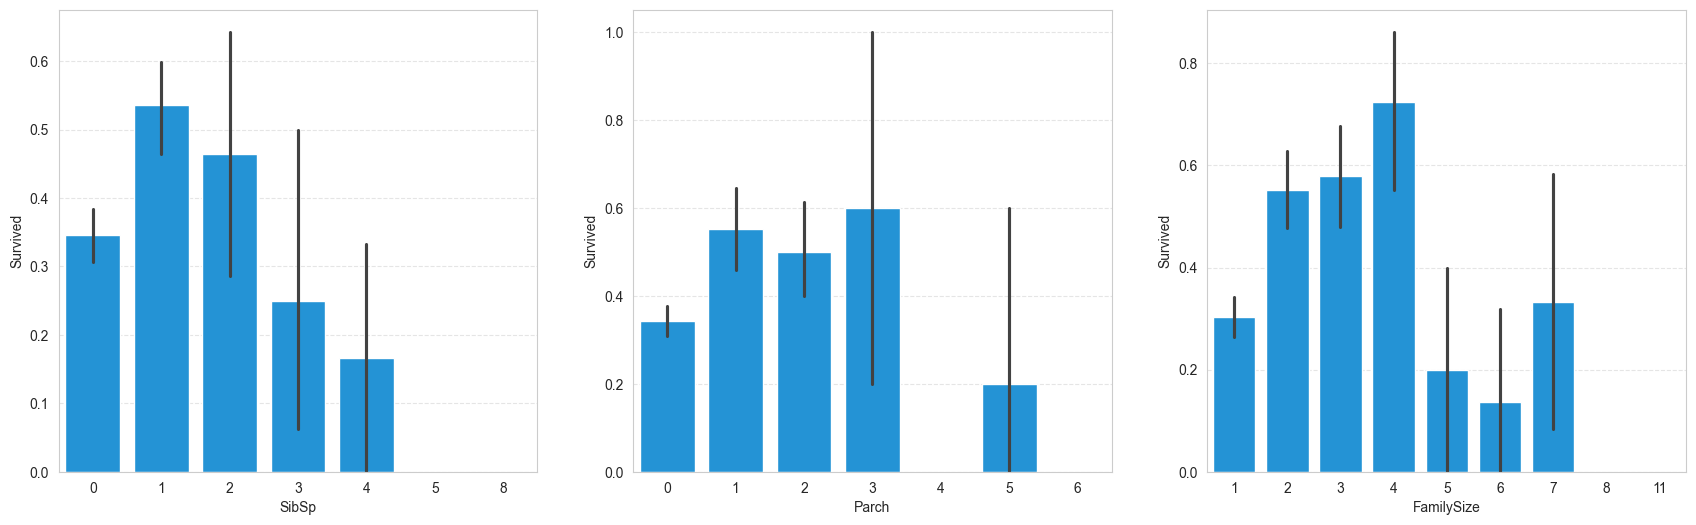

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(21, 6))

sns.barplot(data=train_data_num, x="SibSp", y="Survived", color= COLOR1, ax=ax[0])
sns.barplot(data=train_data_num, x="Parch", y="Survived", color= COLOR1, ax=ax[1])


train_data_num["FamilySize"] = train_data_num["SibSp"] + train_data_num["Parch"] + 1
sns.barplot(
    data=train_data_num,
    x="FamilySize",
    y="Survived",
    color=COLOR1,
    ax=ax[2]
)

ax[0].grid(axis='y', linestyle='--', alpha=0.5)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)
ax[2].grid(axis='y', linestyle='--', alpha=0.5)

### Одна из возможных фич- дублирование пассажир один/не один на круизе

<Axes: xlabel='IsAlone', ylabel='Survived'>

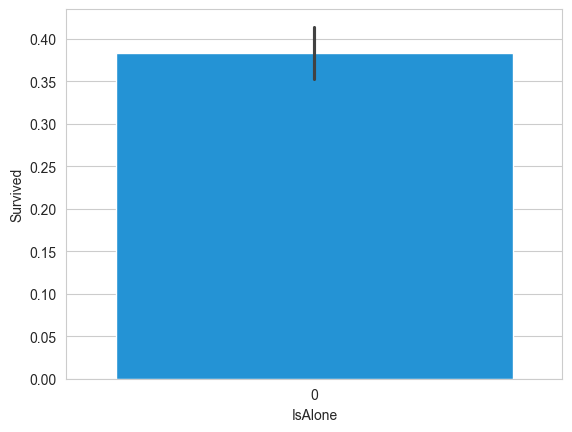

In [16]:
train_data_num["IsAlone"] = (train_data_num["FamilySize"] == 0).astype(int)

sns.barplot(data=train_data_num,
    x="IsAlone",
    y="Survived",
    color=COLOR1)

### Pclass - класс в котором пассажир путешествовал.
Зависимость явная- чем выше класс, тем выше выживаемость.

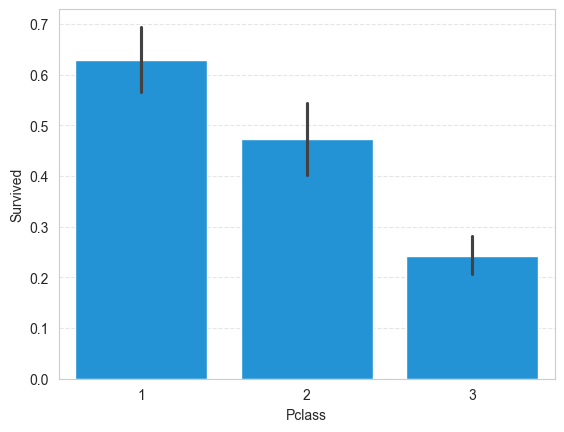

In [17]:
sns.barplot(data=train_data_num, x="Pclass", y="Survived", color= COLOR1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

### Fare - стоимость билета пассажира.  
Распределение стоимости по всем классам вместе- выглядит не релеватно,  
поэтому сначала посмотрим распределение стоимости билетов по классам (PClass),  
а потом разобъем внутри каждого (PClass) выборку на квантильные бины  
и посмотрим на распределение выживаемости от Fare.


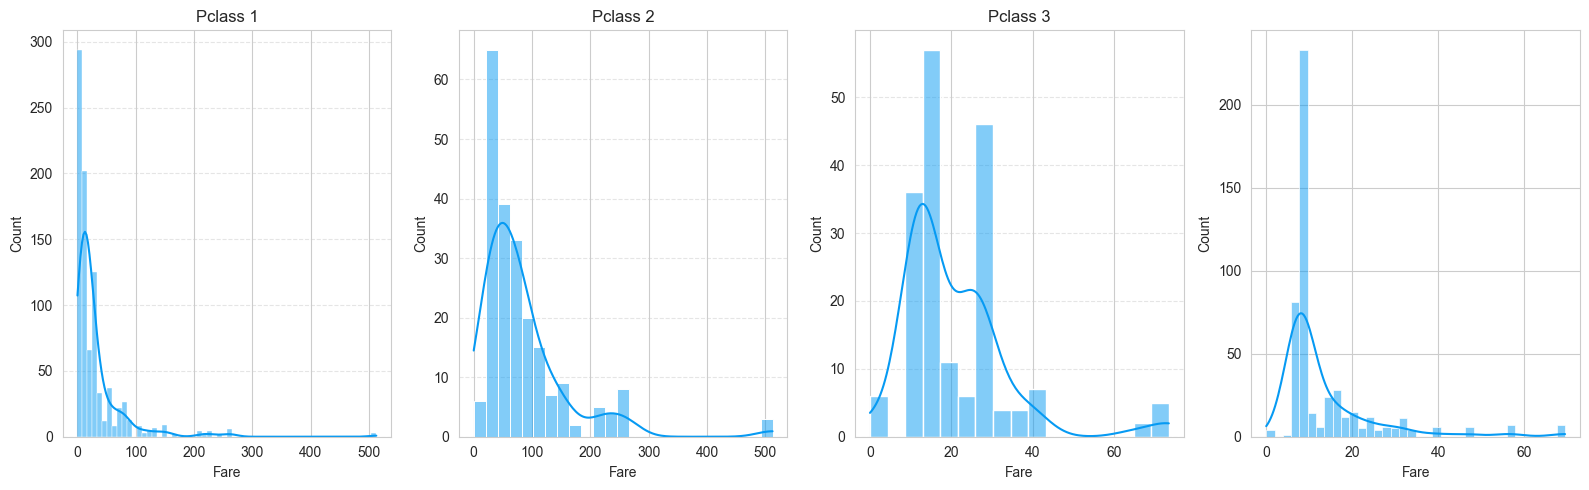

In [19]:
fig, ax = plt.subplots(1, 4, figsize=(16, 5))
sns.histplot(
        train_data_num["Fare"],
        kde=True,
        ax=ax[0], color=COLOR1
)
ax[0].set_title(f"All Pclass")
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

for i, pclass in enumerate([1, 2, 3]):
    
    subset = train_data_num[train_data_num["Pclass"] == pclass]

    sns.histplot(
        subset["Fare"],
        kde=True,
        ax=ax[1+i], color=COLOR1
    )

    ax[i].set_title(f"Pclass {pclass}")
    ax[i].grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()



Во всех трех классах видим хвост справа, уберем его с помощью log(1+x)


In [20]:
train_data_num['FareLog'] = np.log1p(train_data_num['Fare'])

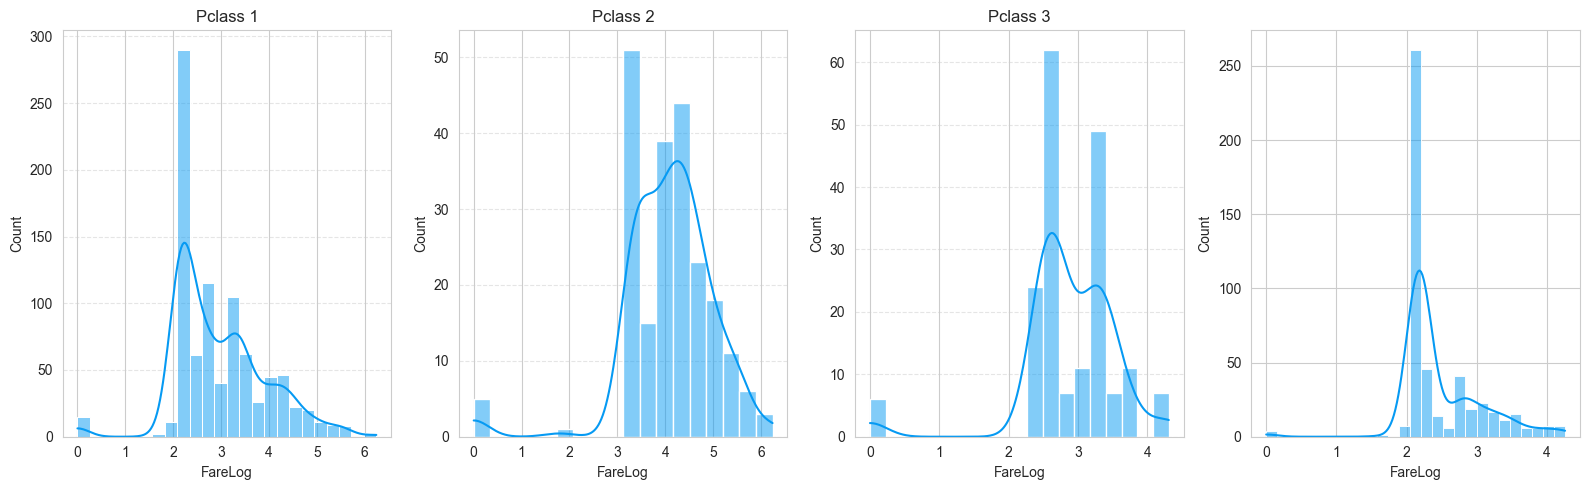

In [21]:
fig, ax = plt.subplots(1, 4, figsize=(16, 5))
sns.histplot(
        train_data_num["FareLog"],
        kde=True,
        ax=ax[0], color=COLOR1
)
ax[0].set_title(f"All Pclass")
ax[0].grid(axis='y', linestyle='--', alpha=0.5)

for i, pclass in enumerate([1, 2, 3]):
    
    subset = train_data_num[train_data_num["Pclass"] == pclass]

    sns.histplot(
        subset["FareLog"],
        kde=True,
        ax=ax[1+i], color=COLOR1
    )

    ax[i].set_title(f"Pclass {pclass}")
    ax[i].grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

Наблюдаем зависимость- чем дороже внутри класса билет- тем выше выживаемость,  
за исключением последнего бина во втором классе (но исходя из CI- это может быть шум)  
и двух последних бинов в PClass=3.

При обучении моделей использовать FareLog или сделать новую фичу, которая учитывает  
стоимость билета внутри класса пассажира, например, FareLog*PClass -  
вопрос открытый.  
А может быть стоит разбивать бины внутри каждого класса отдельно.  
Тем самым будет учитывать насколько стоимость билета дорогая внутри выборки класса.

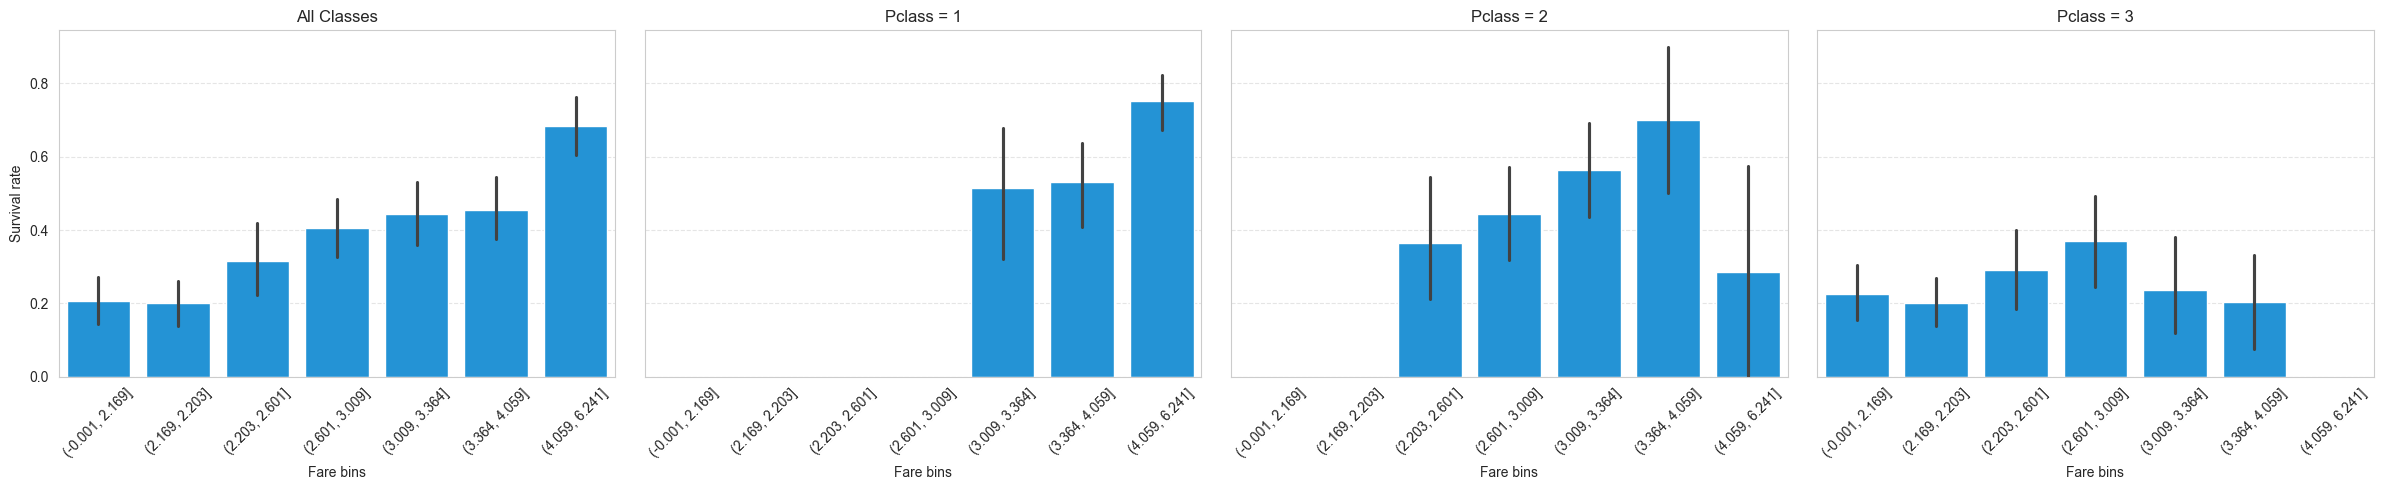

In [22]:
#воспользуемся квантильными бинами
train_data_num['FareBin'] = pd.qcut(
    train_data_num['FareLog'],
    q=7
)


fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharey=True)

sns.barplot(
    data=train_data_num,
    x='FareBin',
    y='Survived',
    errorbar=('ci', 95),
    n_boot=1000,
    color=COLOR1,
    ax=axes[0]
)

axes[0].set_title('All Classes')
axes[0].set_xlabel('Fare bins')
axes[0].set_ylabel('Survival rate')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for i, pclass in enumerate([1, 2, 3], start=1):

    subset = train_data_num[
        train_data_num['Pclass'] == pclass
    ]

    sns.barplot(
        data=subset,
        x='FareBin',
        y='Survived',
        errorbar=('ci', 95),
        n_boot=1000,
        color=COLOR1,
        ax=axes[i]
    )

    axes[i].set_title(f'Pclass = {pclass}')
    axes[i].set_xlabel('Fare bins')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Age
Почти 20% записей не заполнено, сначала посмотрим данные как есть,  
а потом на втором этапе заполним недостающие данные.

<Axes: xlabel='Age', ylabel='Count'>

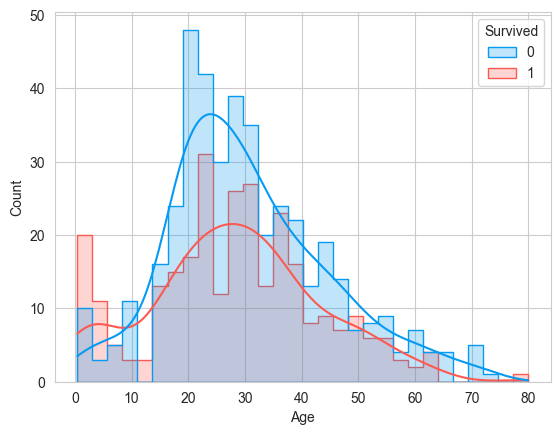

In [23]:

sns.histplot(data=train_data, x="Age", hue="Survived", bins=30, kde=True, element="step", palette= [COLOR1, COLOR2])

Наблюдается близкое к нормальному распределению,  
для более наглядного наблюдения самостоятельно разделим на бины.  
Распределение остается после распределения по бинам близким к нормальному.

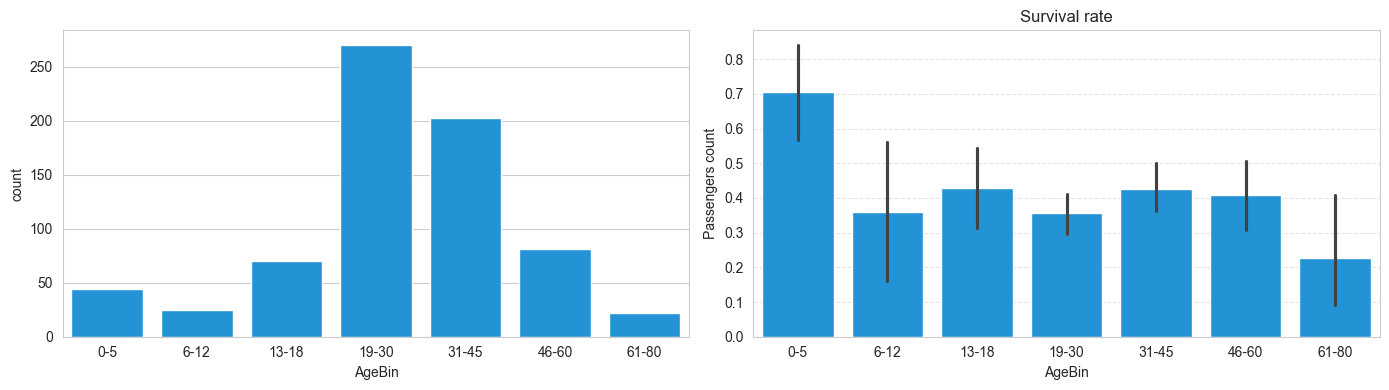

In [24]:
age_bins = [0, 5, 12, 18, 30, 45, 60, 80]
age_labels = ['0-5', '6-12', '13-18', '19-30', '31-45', '46-60', '61-80']

train_data['AgeBin'] = pd.cut(
    train_data['Age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))


sns.countplot(
    data=train_data,
    x='AgeBin',
    color=COLOR1,
    ax= ax[0]
)

sns.barplot(
    data=train_data,
    x='AgeBin',
    y='Survived',
    color=COLOR1,
    ax=ax[1]
)

ax[1].set_title('Survival rate')

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylabel('Passengers count')

plt.show()

train_data.drop('AgeBin',axis=1,inplace=True)

### Cabin
На Kaggle встертил идею- анализировать первую букву каюты, которая обозначает палубу.  
Попробуем посмотреть есть ли зависимость.

In [4]:
train_data["Deck"] = train_data["Cabin"].str[0]

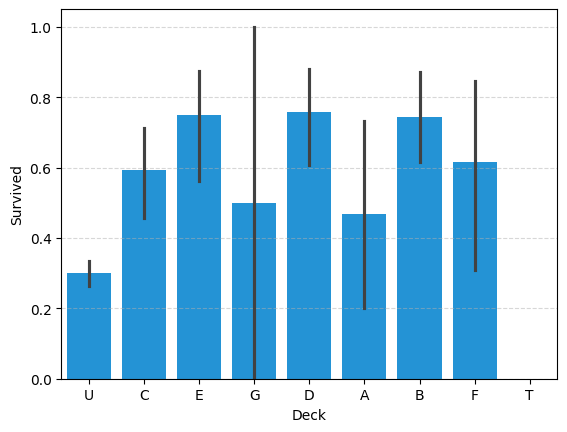

In [ ]:
sns.barplot(data=train_data, x="Deck", y="Survived", color= COLOR1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

In [7]:
#явно видем зависимость, но в часть билетов не заполнена
train_data['Deck'].isnull().sum()

np.int64(687)

In [9]:
train_data['Deck']

0      U
1      C
2      U
3      C
4      U
      ..
886    U
887    B
888    U
889    C
890    U
Name: Deck, Length: 891, dtype: object

In [18]:
train_data['Deck'] = train_data['Cabin'].fillna('U').str[0]

In [11]:
#палуба T - один случай
train_data[train_data['Deck'] == 'T']['Survived']

339    0
Name: Survived, dtype: int64

#### Сведем непопулярные палубы к 'R' (Rare)

In [19]:
train_data['Deck'] = train_data['Deck'].replace(['T', 'G', 'F', 'A'], 'Rare')

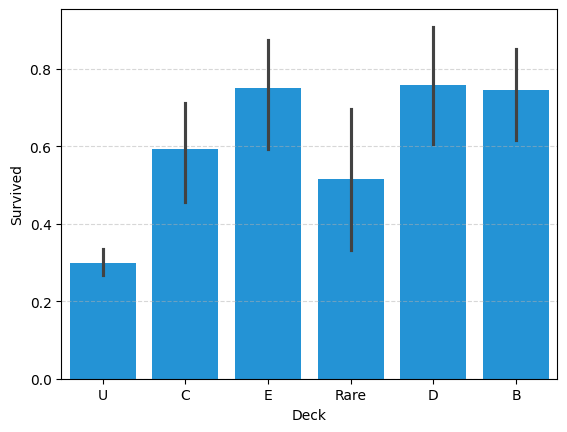

In [11]:
# Достаточно неплохое распределение, без явного шупа по IQ
sns.barplot(data=train_data, x="Deck", y="Survived", color= COLOR1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

In [20]:
train_data = pd.get_dummies(train_data, columns=['Deck'], prefix='Deck', drop_first=True)

In [21]:
train_data.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck_C,Deck_D,Deck_E,Deck_Rare,Deck_U
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,False,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True,False,False,False,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,False,False,False,True


# Далее препроцессинг данных
[Открыть preprocess](preprocess.ipynb)